# Vasicek Interest Rate Model Calibration

This notebook calibrates a Vasicek model to historical 3-month U.S. Treasury yield data sourced from FRED (series: DGS3MO).

The goal is to estimate three parameters - $\kappa$ (mean reversion speed), $\theta$ (long-run mean rate), and $\sigma$ (rate volatility) - along with the current spot rate $r_0$.


### FRED Data: Downloading and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# define where data is
data_dir = "../data/DGS3MO.csv"

#create dataframe and make sure dates are read in as dates
df = pd.read_csv(data_dir, parse_dates=["observation_date"])

#drop blank rows
df = df.dropna()

#rename DGS3MO to rate and observation_date to date
df = df.rename(columns={"DGS3MO": "rate", 'observation_date':'date'})

#divide percent rate by 100 to get decimal
df['rate'] = df['rate']/100

#set date column as index
df = df.set_index('date')

#store spot rate ( most recent rate )
r0 = df["rate"].iloc[-1]
print(f"Spot rate r0 = {r0:.4f}")



Spot rate r0 = 0.0369


### Exploratory Plot

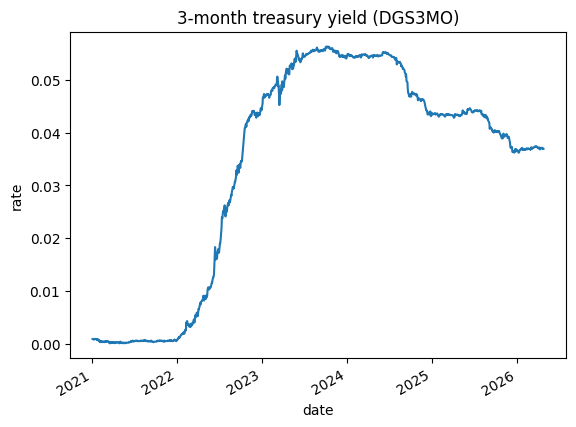

In [3]:
# plot rate vs rate
df['rate'].plot()
plt.title('3-month treasury yield (DGS3MO)')
plt.ylabel('rate')
plt.show()


### Vasicek Calibration (OLS)
We model the short rate as an Ornstein-Uhlenbeck process and calibrate $\kappa$, $\theta$, and $\sigma$ using an AR(1) OLS regression on daily rate changes.

In [4]:
# define our x and y variables as arrays
x = df['rate'].values[:-1]
y = df['rate'].values[1:]

#regression 
b, a = np.polyfit(x,y,1)

# define dt
dt = 1/252

# calculate kappa
kappa = -np.log(b)/dt

#caluclate theta
theta = a/(1-b)

# calculate sigma from residuals
residuals = y - (a + b * x)
sigma_r = np.std(residuals) / np.sqrt(dt)

#print results
print(f"κ  (kappa)     = {kappa:.4f}")
print(f"θ  (theta)     = {theta:.4f}  ({theta*100:.2f}%)")
print(f"σ  (sigma_r)   = {sigma_r:.4f}")
print(f"r0 (spot rate) = {r0:.4f}  ({r0*100:.2f}%)")

# package results
vasicek_params = {
    "kappa": kappa,
    "theta": theta,
    "sigma_r": sigma_r,
    "r0": r0
}

κ  (kappa)     = 0.2704
θ  (theta)     = 0.0591  (5.91%)
σ  (sigma_r)   = 0.0055
r0 (spot rate) = 0.0369  (3.69%)


### Validation - Simulated Rate Paths
Simulating future paths using our calibrated parameters and visually confirm they mean revert toward $\theta$.

In [5]:
# simulate 1000 paths starting at r0
n_steps = 252*2
n_paths = 100
matrix = np.zeros((n_steps,n_paths))
matrix[0]=r0

for t in range(1, n_steps):
    Z = np.random.randn(n_paths)
    matrix[t] = matrix[t-1] + kappa*(theta - matrix[t-1])*dt + sigma_r*np.sqrt(dt)*Z
    

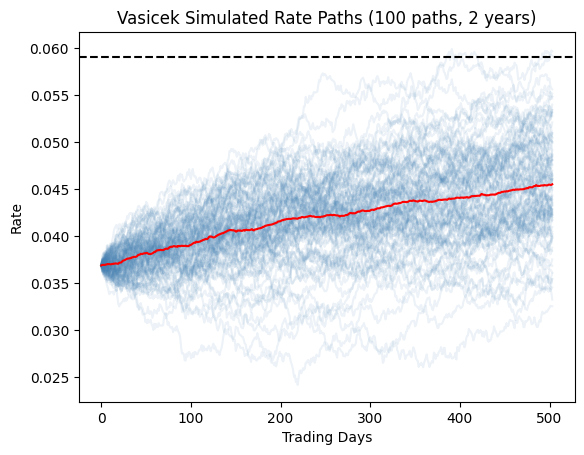

In [6]:
#plot the simulation
plt.plot(matrix, color='steelblue', alpha = .1)
plt.plot(matrix.mean(axis=1), color='red')
plt.axhline(y=theta,color='black',linestyle='--')
plt.title("Vasicek Simulated Rate Paths (100 paths, 2 years)")
plt.ylabel("Rate")
plt.xlabel("Trading Days")
plt.show()

In [7]:
import json

with open("../data/vasicek_params.json", "w") as f:
    json.dump(vasicek_params, f, indent=4)
    
print("vasicek_params saved to ../data/vasicek_params.json")

vasicek_params saved to ../data/vasicek_params.json
